PUNTO 1

In [ ]:
import numpy as np
from numpy import deg2rad, rad2deg
from sympy import symbols, Matrix, sqrt, atan2, cos, sin, Eq, simplify, N
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols
from IPython.display import display, Math
from sympy import init_printing
init_printing(use_latex=True)

# Datos del enunciado
Lf = 0.75                               # segmento fijo del brazo [m]
Qx, Qy = 0.8, 1.3                       # posición objetivo Q [m]
Px, Py = 1.0, 1.0                       # anclaje del resorte P [m]
k  = 1500.0                             # N/m  (k = 1.5 kN/m)
L0 = 0.20                               # longitud natural [m]

# 1) IK cerrada para (theta, l)
#     r_Q = (Lf + l) [cos th, sin th]^T = Q
rQ = Matrix([Qx, Qy])
a = float(np.sqrt(Qx**2 + Qy**2))       # a = Lf + l
theta = float(np.arctan2(Qy, Qx))       # rad
l = a - Lf                              # m

# 2) Fuerza de resorte que actúa sobre la garra (en Q)
#     F_s = k (||QP||-L0) * (QP/||QP||)
rQP = Matrix([Px - Qx, Py - Qy])        # vector Q->P
ell = float(np.sqrt((Px-Qx)**2 + (Py-Qy)**2))
stretch = ell - L0
Fs_mag = k * stretch                    # N
uQP = rQP/ell                           # unitario
Fs = Fs_mag * uQP                       # vector fuerza sobre la garra (del resorte)

# 3) Jacobiano y esfuerzos articulares   tau = J^T F_s
th = theta
J = Matrix([[-a*np.sin(th), np.cos(th)],
            [ a*np.cos(th), np.sin(th)]])   # J(θ,l) con a=Lf+l
tau_theta, F_l = (J.T * Fs)

# Simplificar
tau_theta = N(simplify(tau_theta))
F_l       = N(simplify(F_l))

print(f"MOMENTO MOTOR tau_theta = {float(tau_theta):.3f} N·m")
print(f"LINEAL F_l = {float(F_l):.3f} N  (positivo en +x_B, a lo largo del brazo)")


MOMENTO MOTOR tau_theta = -333.975 N·m
LINEAL F_l = -100.645 N  (positivo en +x_B, a lo largo del brazo)


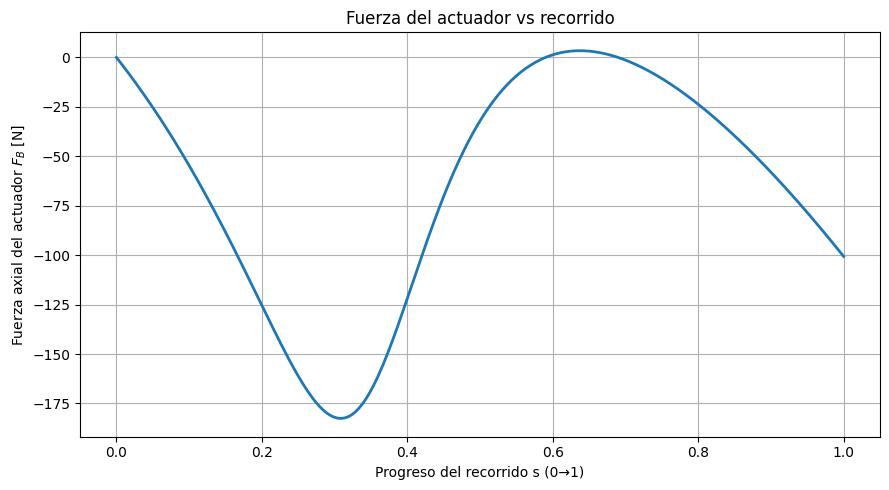

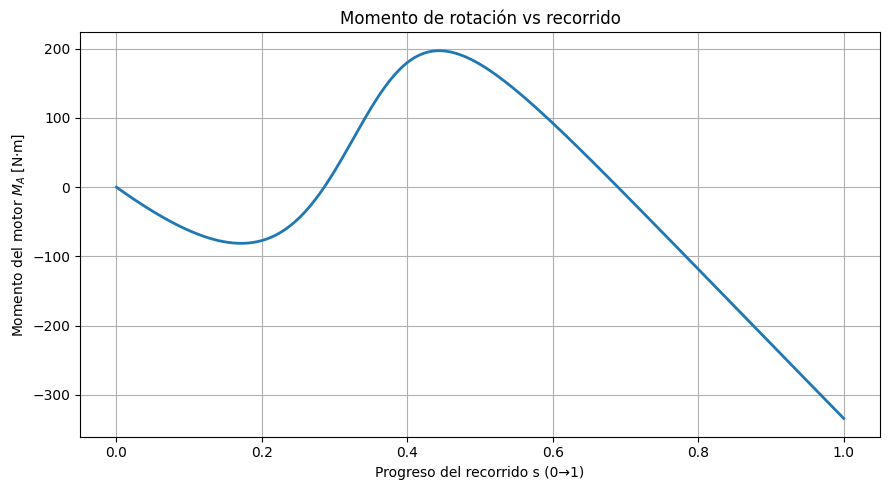

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Parámetros del problema -------------------
k = 1500.0          # [N/m] rigidez del resorte
L0 = 0.20           # [m]   longitud natural del resorte
P = np.array([1.0, 1.0])   # [m] anclaje del resorte
L_base = 0.75       # [m]   tramo fijo del brazo

Q_start = np.array([1.0, 0.8])  # inicio del recorrido
Q_goal  = np.array([0.8, 1.3])  # punto Q de destino

# -------------- Utilidades geométricas/físicas --------------
def kinematics_from_Q(Q: np.ndarray, L_base: float):
    R = np.linalg.norm(Q)
    theta = np.arctan2(Q[1], Q[0])
    l = R - L_base
    e_r = np.array([np.cos(theta), np.sin(theta)])
    return theta, l, e_r

def spring_force(P: np.ndarray, Q: np.ndarray, k: float, L0: float):
    vec = P - Q
    L = np.linalg.norm(vec)
    u = vec / L
    F = k * (L - L0) * u
    return F, L

def actuator_force_and_torque(Q: np.ndarray, P: np.ndarray, k: float, L0: float, L_base: float):
    theta, l, e_r = kinematics_from_Q(Q, L_base)
    F_spring, L = spring_force(P, Q, k, L0)
    F_act = F_spring @ e_r
    tau = Q[0]*F_spring[1] - Q[1]*F_spring[0]  # r x F (z)
    return F_act, tau, theta, l, L

# ------------------- Recorrido y cálculo --------------------
Npts = 301
s = np.linspace(0.0, 1.0, Npts)
Q_path = (1 - s)[:, None]*Q_start + s[:, None]*Q_goal

F_act_hist = np.zeros(Npts)
Tau_hist   = np.zeros(Npts)
theta_hist = np.zeros(Npts)
l_hist     = np.zeros(Npts)
L_hist     = np.zeros(Npts)

for i, Q in enumerate(Q_path):
    F_act, tau, theta, l, L = actuator_force_and_torque(Q, P, k, L0, L_base)
    F_act_hist[i] = F_act
    Tau_hist[i]   = tau
    theta_hist[i] = theta
    l_hist[i]     = l
    L_hist[i]     = L

# ------------------------- Gráficas -------------------------
plt.figure(figsize=(9,5))
plt.plot(s, F_act_hist, linewidth=2)
plt.xlabel("Progreso del recorrido s (0→1)")
plt.ylabel("Fuerza axial del actuador $F_B$ [N]")
plt.title("Fuerza del actuador vs recorrido")
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(9,5))
plt.plot(s, Tau_hist, linewidth=2)
plt.xlabel("Progreso del recorrido s (0→1)")
plt.ylabel("Momento del motor $M_A$ [N·m]")
plt.title("Momento de rotación vs recorrido")
plt.grid(True)
plt.tight_layout()
plt.show()


PUNTO 2

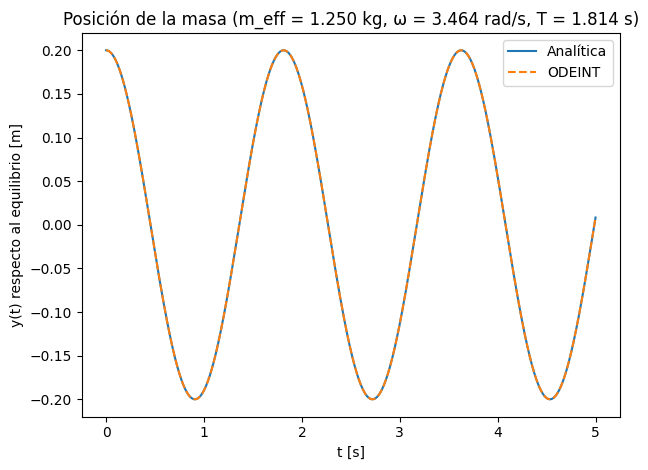

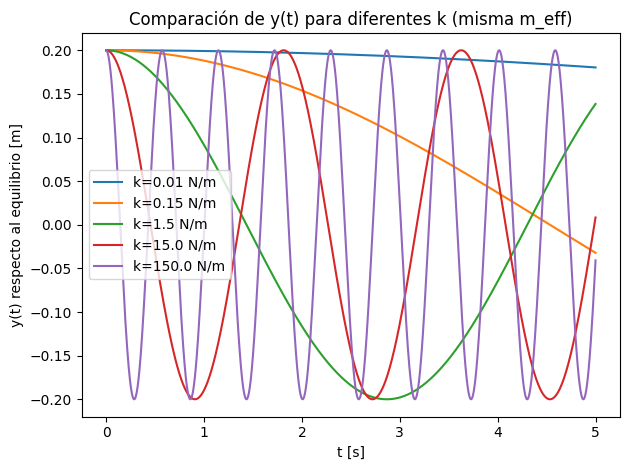

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parámetros del enunciado
m = 0.5       # kg (masa colgante)
m_p = 1.5     # kg (masa de la polea)
k = 15.0      # N/m (rigidez del resorte)
R = 0.12      # m (radio de la polea)

# Inercia de la polea: I = (1/2) m_p R^2
I = 0.5 * m_p * R**2

# "Masa efectiva" por la inercia rotacional de la polea
# m_eff = m + I/R^2 = m + (1/2) m_p
m_eff = m + I / R**2

# Condición inicial: se estira 0.2 m adicionales y se suelta desde reposo
y0 = 0.2   # m  (desplazamiento adicional respecto al equilibrio estático)
v0 = 0.0   # m/s

# Mallado temporal
t = np.linspace(0.0, 5.0, 2001)  # 0–5 s

# Solución analítica
omega = np.sqrt(k / m_eff)
T = 2*np.pi / omega
y_analytic = y0 * np.cos(omega * t) + (v0/omega) * np.sin(omega * t)

# Solución numérica con ODEINT
#   Estado: x = [y, v]
#   y' = v
#   v' = -(k/m_eff) y
def f(x, _t):
    y, v = x
    dv = -(k/m_eff) * y
    return [v, dv]

x_ini = [y0, v0]
sol = odeint(f, x_ini, t)
y_ode = sol[:, 0]

# Gráficas

# 1) Caso base: comparación analítica vs ODE
plt.figure()
plt.plot(t, y_analytic, label="Analítica")
plt.plot(t, y_ode, linestyle="--", label="ODEINT")
plt.xlabel("t [s]")
plt.ylabel("y(t) respecto al equilibrio [m]")
plt.title(f"Posición de la masa (m_eff = {m_eff:.3f} kg, ω = {omega:.3f} rad/s, T = {T:.3f} s)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Opcional avanzado: barrido de k
k_values = [0.01, 0.15, 1.5, 15.0, 150.0]  # N/m
plt.figure()
for k_i in k_values:
    omega_i = np.sqrt(k_i / m_eff)
    y_i = y0 * np.cos(omega_i * t)  # v0 = 0
    plt.plot(t, y_i, label=f"k={k_i} N/m")
plt.xlabel("t [s]")
plt.ylabel("y(t) respecto al equilibrio [m]")
plt.title("Comparación de y(t) para diferentes k (misma m_eff)")
plt.legend()
plt.tight_layout()
plt.show()


Se observa que la rigidez del resorte influye directamente en la frecuencia de oscilación. Para valores pequeños de k el movimiento es más lento y con pocas oscilaciones, mientras que para valores grandes de k, las oscilaciones son mucho más rápidas y hay más. A pesar de que la amplitud inicial es la misma en todos los casos, las velocidades y aceleraciones máximas aumentan con k, ya que la energía almacenada en el resorte es proporcional a su rigidez.

PUNTO 3 

s =  0.1 m  ->  Fext = -0.3264 N, N_A = 0.3264 N,  N_B = 9.7798 N
s =  1.4 m  ->  Fext = -11.6280 N, N_A = 11.6280 N,  N_B = 9.1617 N


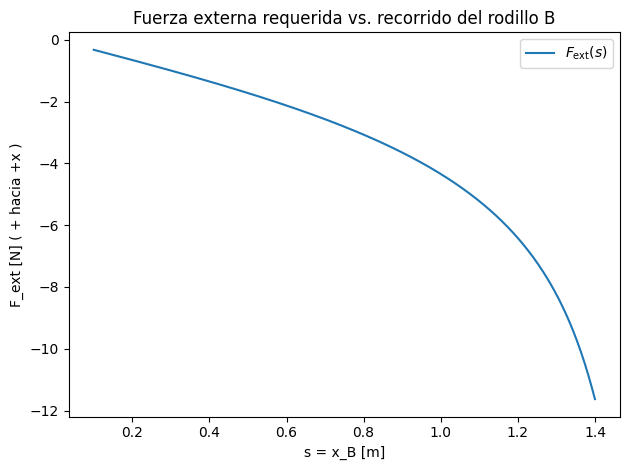

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve, simplify, sqrt, lambdify, N

# 1) Símbolos, parámetros y cinemática
L, m, g = symbols('L m g', positive=True)
x, vB = symbols('x v_B', real=True)    # x ≡ s
NA, NB, Fext = symbols('N_A N_B F_{ext}', real=True)
IG = (m*L**2)/12

# Geometría (A en pared vertical, B en piso horizontal)
y = sqrt(L**2 - x**2)                  # altura de A

# Cinemática para vB = const -> aB = 0
omega = vB / y                         # ω = vB / y
alpha = vB**2 * x / y**3               # α = dω/dt
aGx = 0
aGy = -(vB**2 * L**2) / (2*y**3)       # aceleración vertical del centro G

# 2) Ecuaciones dinámicas 
#    ΣFx = m a_Gx
#    ΣFy = m a_Gy
#    ΣM_G = I_G α
eq_fx = Eq(NA + Fext, m*aGx)
eq_fy = Eq(NB - m*g, m*aGy)
eq_MG = Eq(-(y/2)*NA + (x/2)*NB + (y/2)*Fext, IG*alpha)

sol = solve([eq_fx, eq_fy, eq_MG], [NA, NB, Fext], dict=True)[0]
NA_sym = simplify(sol[NA])
NB_sym = simplify(sol[NB])
Fext_sym = simplify(sol[Fext])

# 3) Numerizar + vectorizar (lambdify)
params = {L: 1.5, m: 1.0, g: 9.81, vB: 0.3}

Fext_fun = lambdify(x, Fext_sym.subs(params), "numpy")
NA_fun   = lambdify(x, NA_sym.subs(params), "numpy")
NB_fun   = lambdify(x, NB_sym.subs(params), "numpy")

# Rango solicitado
s = np.linspace(0.1, 1.4, 400)  # m

Fext_vals = Fext_fun(s)
NA_vals   = NA_fun(s)
NB_vals   = NB_fun(s)

# Valores en los extremos
for s_eval in [0.1, 1.4]:
    print(f"s = {s_eval:>4.1f} m  ->  Fext = {float(Fext_fun(s_eval)):.4f} N, "
          f"N_A = {float(NA_fun(s_eval)):.4f} N,  N_B = {float(NB_fun(s_eval)):.4f} N")

# 4) Gráficas
plt.figure()
plt.plot(s, Fext_vals, label=r"$F_{\rm ext}(s)$")
plt.xlabel("s = x_B [m]")
plt.ylabel("F_ext [N] ( + hacia +x )")
plt.title("Fuerza externa requerida vs. recorrido del rodillo B")
plt.legend()
plt.tight_layout()
plt.show()


Fext=   1.0 N  ->  alcanza s=1.4 m a t ≈ 0.7570 s, v ≈ 2.162 m/s
Fext=  10.0 N  ->  alcanza s=1.4 m a t ≈ 0.3270 s, v ≈ 3.751 m/s
Fext= 100.0 N  ->  alcanza s=1.4 m a t ≈ 0.1100 s, v ≈ 10.296 m/s


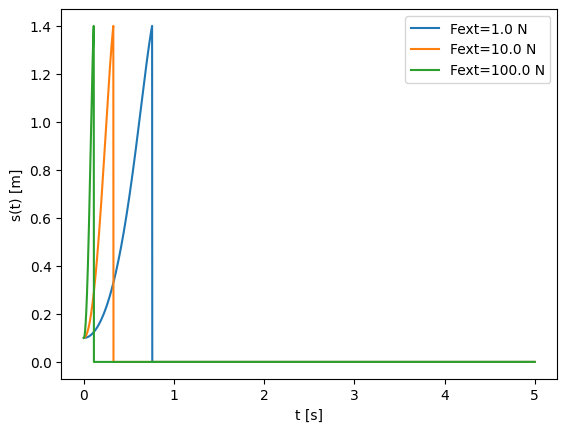

In [ ]:
# Dinámica directa de la barra
# Fext = 1, 10, 100 N. Condiciones: x(0)=0.1 m, xdot(0)=0.
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve, simplify, sqrt, lambdify

# 1) Derivación de xddot = f(x, xdot; Fext)
L, m, g = symbols('L m g', positive=True)
x, xdot, xddot, Fext = symbols('x xdot xddot Fext', real=True)
NA, NB = symbols('NA NB', real=True)
IG = m*L**2/12

y = sqrt(L**2 - x**2)
ydot  = (-x/y) * xdot
yddot = (-L**2 / y**3) * xdot**2 + (-x / y) * xddot  # via y'' = -L^2/y^3

omega = xdot / y
alpha = xddot / y + x * xdot**2 / y**3

aGx = 0.5 * xddot
aGy = 0.5 * yddot

eq_fx = Eq(NA + Fext, m * aGx)
eq_fy = Eq(NB - m * g, m * aGy)
eq_MG = Eq(-(y/2)*NA + (x/2)*NB + (y/2)*Fext, IG * alpha)

sol = solve([eq_fx, eq_fy, eq_MG], [NA, NB, xddot], dict=True)[0]
xddot_expr = simplify(sol[xddot])

xddot_fun = lambdify((x, xdot, Fext, L, m, g), xddot_expr, "numpy")

# 2) Integración (RK4)
def simulate(F, x0=0.1, v0=0.0, t_end=5.0, dt=1e-3, L_val=1.5, m_val=1.0, g_val=9.81):
    n = int(t_end/dt)+1
    t = np.linspace(0.0, t_end, n)
    x = np.zeros(n); v = np.zeros(n)
    x[0], v[0] = x0, v0
    for i in range(n-1):
        # Stop al llegar al tope geométrico s=1.4 m
        if x[i] >= 1.4:
            x[i+1:] = x[i]; v[i+1:] = 0.0
            break
        # RK4
        k1x = v[i]
        k1v = xddot_fun(x[i], v[i], F, L_val, m_val, g_val)
        k2x = v[i] + 0.5*dt*k1v
        k2v = xddot_fun(x[i] + 0.5*dt*k1x, v[i] + 0.5*dt*k1v, F, L_val, m_val, g_val)
        k3x = v[i] + 0.5*dt*k2v
        k3v = xddot_fun(x[i] + 0.5*dt*k2x, v[i] + 0.5*dt*k2v, F, L_val, m_val, g_val)
        k4x = v[i] + dt*k3v
        k4v = xddot_fun(x[i] + dt*k3x, v[i] + dt*k3v, F, L_val, m_val, g_val)
        x[i+1] = x[i] + (dt/6)*(k1x + 2*k2x + 2*k3x + k4x)
        v[i+1] = v[i] + (dt/6)*(k1v + 2*k2v + 2*k3v + k4v)
        if x[i+1] >= 1.4:
            x[i+1] = 1.4; v[i+1] = 0.0
            break
    return t, x, v

# 3) Correr casos y graficar
cases = [1.0, 10.0, 100.0]
results = {F: simulate(F) for F in cases}

# Ejemplo de impresión de tiempo para alcanzar s=1.4 m
for F in cases:
    t, x, v = results[F]
    hit = np.argmax(x >= 1.4) if np.any(x >= 1.4) else None
    if hit is not None and hit > 0:
        print(f"Fext={F:>6.1f} N  ->  alcanza s=1.4 m a t ≈ {t[hit]:.4f} s, v ≈ {v[hit-1]:.3f} m/s")

# Graficar:
import matplotlib.pyplot as plt
plt.figure(); 
for F in cases: t,x,v = results[F]; plt.plot(t,x,label=f"Fext={F} N")
plt.xlabel("t [s]"); plt.ylabel("s(t) [m]"); plt.legend(); plt.show()


PUNTO 4

In [ ]:
import numpy as np
from sympy import symbols, Eq, solve, pi, sin, diff, E, lambdify, N

# Datos 
m   = 43.0        # kg
L   = 0.44        # m (longitud del torso modelado como barra delgada)
rT  = 0.22        # m (punto de aplicación de la cuerda medido desde el pivote)
g   = 9.81        # m/s^2
phi0_deg = 30.0   # ángulo de la barra respecto a la vertical en t=0
phi0 = np.deg2rad(phi0_deg)

# Cinemática del toro: θ(t) = 1.5 e^t - 1.5 - t + π/2
# Necesitamos α(0) = θ¨(0)
t = symbols('t', real=True)
theta = 1.5*E**t - 1.5 - t + pi/2
alpha_t = diff(theta, t, 2)     # 2da derivada
alpha0 = float(N(alpha_t.subs(t, 0)))   # = 1.5 rad/s^2

# Inercia de barra delgada respecto a un extremo (pivote en la silla)
I_A = (1.0/3.0)*m*L**2

# Momentos respecto al pivote (sentido positivo = mismo de θ)
#   - T crea τ_T = T * rT * sin(phi0) (fuerza horizontal aplicada a distancia rT)
#   - Peso crea τ_g = - m g (L/2) sin(phi0) (tiende a tumbar hacia abajo)
# Ecuación dinámica:  τ_T + τ_g = I_A * α(0)
# Se despeja T
numerador = I_A*alpha0 + m*g*(L/2.0)*np.sin(phi0)
denominador = rT*np.sin(phi0)
T = numerador/denominador

# Reporte
print("instante inicial (t = 0 s)")
print(f"Momento por peso τ_g = {- m*g*(L/2.0)*np.sin(phi0):.6g} N·m")
print(f"Tensión requerida T = {T:.6g} N")



instante inicial (t = 0 s)
Momento por peso τ_g = -46.4013 N·m
Tensión requerida T = 459.67 N


Tensión mínima   : 458.9500951270297 N
Tensión máxima   : 459.9062591770243 N


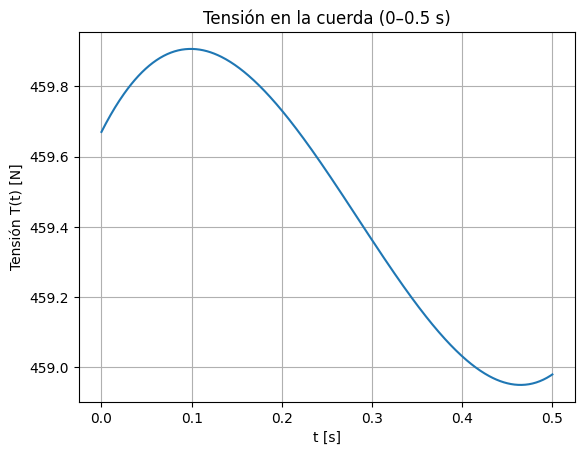

In [16]:
#AVANZADO OPCIONAL 
import numpy as np
import math
import matplotlib.pyplot as plt

# Parámetros
m   = 43.0          # kg
L   = 0.44          # m
rT  = 0.22          # m
g   = 9.81          # m/s^2
phi0_deg = 30.0     # °
phi0 = math.radians(phi0_deg)
I_A = (1.0/3.0)*m*L**2

# Cinemática del toro
def theta(t):   return 1.5*math.e**t - 1.5 - t + math.pi/2
def alpha(t):   return 1.5*math.e**t           # θ¨(t)
theta0 = theta(0.0)

# Tensión
def T(t):
    phi = phi0 + (theta(t) - theta0)          # mantener ángulo relativo
    s   = math.sin(phi)
    if abs(s) < 1e-6:
        return np.nan                         # singular (cuerda no genera momento)
    return (I_A*alpha(t) + m*g*(L/2.0)*s) / (rT*s)

# Malla temporal y evaluación
t_grid = np.linspace(0.0, 0.5, 501)
T_vals = np.array([T(t) for t in t_grid])

# Resumen numérico
T_min = np.nanmin(T_vals)
T_max = np.nanmax(T_vals)
print("Tensión mínima   :", T_min, "N")
print("Tensión máxima   :", T_max, "N")

# Gráfica
plt.figure()
plt.plot(t_grid, T_vals)
plt.xlabel("t [s]")
plt.ylabel("Tensión T(t) [N]")
plt.title("Tensión en la cuerda (0–0.5 s)")
plt.grid(True)
plt.show()


Durante el movimiento del toro mecánico, la tensión en la cuerda permanece prácticamente constante, cercana a 460 N, y nunca se vuelve infinita, lo que indica que la cuerda mantiene un brazo de palanca efectivo durante todo el recorrido. Dado que el seno del ángulo 𝜙(𝑡) no llega a ser cero, la cuerda puede seguir generando el momento necesario para equilibrar el peso del torso y producir la aceleración angular impuesta por el toro. Por tanto, el torso del vaquero sí puede sostenerse únicamente con la tensión de la cuerda en los primeros 0,5 s.